In [1]:
import pandas as pd
import numpy as np

In [2]:
import random

In [3]:
import torch

In [4]:
sensitive_boundaries_results_path = "/scratch1/smaruj/sensitive_boundary_results.tsv"

In [5]:
df = pd.read_csv(sensitive_boundaries_results_path, sep="\t")

In [6]:
import ast

In [7]:
df["disrupted_bin"] = df["disrupted_bin"].apply(ast.literal_eval)

In [8]:
filtered_sorted_neg_df = (
    df[df["DeltaBoundaryStrength"] < 0]
    .sort_values(by="DeltaBoundaryStrength")
    .reset_index(drop=True)
)

In [9]:
filtered_sorted_neg_df

,chrom,start,end,window_end,window_start,disrupted_bin,SCD,DeltaBoundaryStrength
0,chr5,5470000,5480000,6131504,4820784,"[258, 264]",41.033791,-0.143692
1,chr13,53770000,53780000,54431504,53120784,"[255, 259, 250]",39.099865,-0.141888
2,chr18,76350000,76360000,77011504,75700784,"[252, 264, 265, 267]",36.822563,-0.123554
3,chr5,98340000,98350000,99001504,97690784,"[247, 255, 257, 264]",32.557678,-0.116049
4,chr4,118980000,118990000,119641504,118330784,"[253, 257, 258, 265]",45.330536,-0.113569
...,...,...,...,...,...,...,...,...
1373,chr5,147360000,147370000,148021504,146710784,[251],1.449261,-0.000014
1374,chr18,43530000,43540000,44191504,42880784,"[249, 265]",2.262964,-0.000013
1375,chr12,5400000,5410000,6061504,4750784,"[258, 263]",1.109473,-0.000011
1376,chr4,81550000,81560000,82211504,80900784,[260],5.634370,-0.000006


In [10]:
import matplotlib.pyplot as plt


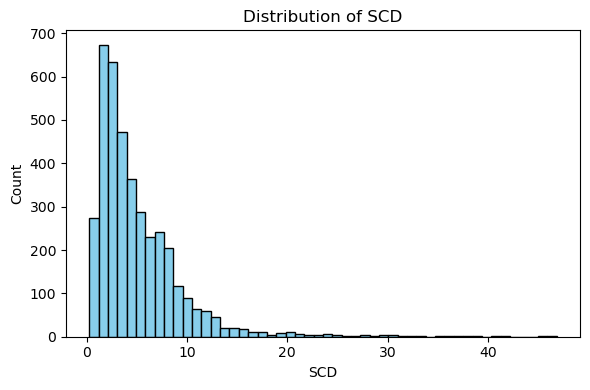

In [11]:
# Plot SCD histogram
plt.figure(figsize=(6, 4))
plt.hist(df["SCD"], bins=50, color="skyblue", edgecolor="black")
plt.title("Distribution of SCD")
plt.xlabel("SCD")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

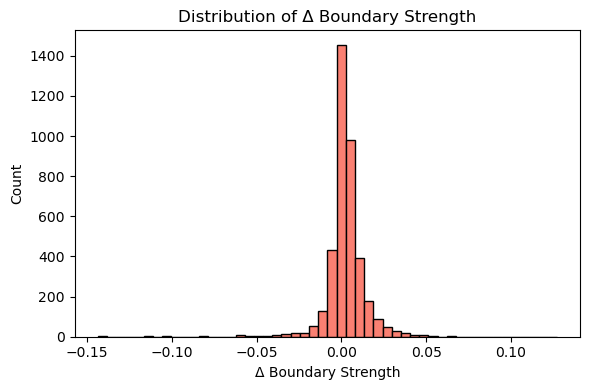

In [12]:
# Plot DeltaBoundaryStrength histogram
plt.figure(figsize=(6, 4))
plt.hist(df["DeltaBoundaryStrength"], bins=50, color="salmon", edgecolor="black")
plt.title("Distribution of Δ Boundary Strength")
plt.xlabel("Δ Boundary Strength")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [13]:
df["DeltaBoundaryStrength"].max()

0.12721065

In [14]:
df["DeltaBoundaryStrength"].mean()

0.0025363942265071264

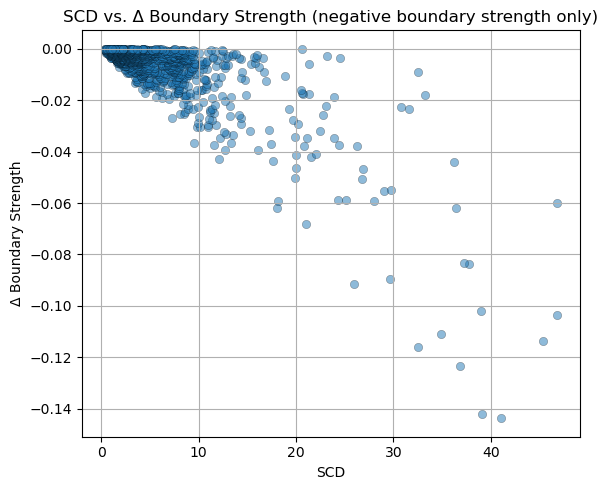

In [15]:
plt.figure(figsize=(6, 5))
plt.scatter(
    filtered_sorted_neg_df["SCD"],
    filtered_sorted_neg_df["DeltaBoundaryStrength"],
    alpha=0.5,
    edgecolors="k",
    linewidths=0.3
)
plt.title("SCD vs. Δ Boundary Strength (negative boundary strength only)")
plt.xlabel("SCD")
plt.ylabel("Δ Boundary Strength")
plt.grid(True)
plt.tight_layout()
plt.show()

## CTCFs analysis

In [16]:
def one_hot_encode_sequence(sequence_obj):
    # Convert pyfaidx.Sequence object to string
    sequence = str(sequence_obj).upper()
    
    # Define the mapping from bases to integers
    base_to_int = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    valid_bases = list(base_to_int.keys())

    # Step 1: Convert sequence to integer encoding with random base for 'N'
    encoded_indices = []
    for base in sequence:
        if base in base_to_int:
            encoded_indices.append(base_to_int[base])
        else:
            random_base = random.choice(valid_bases)
            encoded_indices.append(base_to_int[random_base])

    # Step 2: One-hot encode the sequence
    encoded_sequence = np.array(encoded_indices, dtype=int)
    one_hot_encoded = np.zeros((4, len(encoded_sequence)), dtype=np.float32)
    one_hot_encoded[encoded_sequence, np.arange(len(encoded_sequence))] = 1

    return one_hot_encoded

In [17]:
from pyfaidx import Fasta

In [18]:
fasta_file = "/project/fudenber_735/genomes/hg38/hg38.fa"
genome = Fasta(fasta_file)

In [19]:
def group_consecutive_bins(bins):
    bins = sorted(bins)
    grouped = []
    current_group = [bins[0]]

    for b in bins[1:]:
        if b == current_group[-1] + 1:
            current_group.append(b)
        else:
            grouped.append(current_group)
            current_group = [b]
    grouped.append(current_group)
    return grouped

In [20]:
def get_sequence(genome, chrom, start, bin_list, cropping=64, bin_size=2048):
    if len(bin_list) == 1:
        bin_start = start + (bin_list[0] + cropping) * bin_size
        bin_end = bin_start + bin_size
    else:
        bin_start = start + (min(bin_list) + cropping) * bin_size
        bin_end = bin_start + len(bin_list) * bin_size
    seq = genome[chrom][bin_start:bin_end].seq.upper()
    ohe_seq = one_hot_encode_sequence(seq)
    return np.expand_dims(ohe_seq, axis=0)

In [21]:
CTCF_PWM = "/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"

In [22]:
def read_meme_pwm_as_numpy(filename):
    pwm_list = []  # List to store PWM rows
    
    with open(filename, 'r') as file:
        in_matrix_section = False
        
        for line in file:
            line = line.strip()
            
            # Check if we are reading the PWM matrix
            if line.startswith("letter-probability matrix"):
                in_matrix_section = True  # Start reading matrix data
                continue  # Skip this header line
            
            # If we are in the matrix section, process the rows
            if in_matrix_section and line:
                pwm_row = [float(value) for value in line.split()]  # Parse values
                pwm_list.append(pwm_row)  # Append to the PWM list
            
            # If we encounter a new MOTIF or the end of file, stop matrix reading
            if line.startswith("MOTIF") and in_matrix_section:
                break
    
    # Convert the list to a numpy array
    pwm_array = np.array(pwm_list)
    
    return pwm_array

In [23]:
pwm_CTCF = read_meme_pwm_as_numpy(CTCF_PWM)

In [24]:
pwm_CTCF_tensor = torch.from_numpy(pwm_CTCF.T).float()

In [25]:
motifs_dict = {"CTCF": pwm_CTCF_tensor}

In [26]:
from tangermeme.tools import fimo

In [33]:
all_hits = []

for idx, row in filtered_sorted_neg_df.iterrows():
    chrom = row["chrom"]
    window_start = row["window_start"]
    window_end = row["window_end"]
    scd = row["SCD"]
    bound_strength = row["DeltaBoundaryStrength"]
    all_bins = row["disrupted_bin"]
    grouped_bins = group_consecutive_bins(all_bins)
    
    for gr_bins in grouped_bins:
        sequence = get_sequence(genome, chrom, window_start, gr_bins)

        hits = fimo.fimo(
            motifs=motifs_dict,
            sequences=sequence,
            threshold=1e-4,
            reverse_complement=True
        )[0]

        # Only add non-empty results
        if not hits.empty:
            hits["chrom"] = chrom
            hits["window_start"] = window_start
            hits["window_end"] = window_end
            hits["bin_group"] = str(gr_bins)
            hits["scd"] = scd
            hits["bound_strength"] = bound_strength
            all_hits.append(hits)

In [34]:
combined_hits_df = pd.concat(all_hits, ignore_index=True)

In [35]:
combined_hits_df

,motif_name,motif_idx,sequence_name,start,end,strand,score,p-value,chrom,window_start,window_end,bin_group,scd,bound_strength
0,CTCF,0,0,6,25,+,17.016524,0.000001,chr5,4820784,6131504,[264],41.033791,-0.143692
1,CTCF,0,0,527,546,-,8.756583,0.000087,chr13,53120784,54431504,[255],39.099865,-0.141888
2,CTCF,0,0,290,309,+,16.950388,0.000001,chr13,53120784,54431504,[259],39.099865,-0.141888
3,CTCF,0,0,1157,1176,-,12.410929,0.000015,chr13,53120784,54431504,[259],39.099865,-0.141888
4,CTCF,0,0,1303,1322,-,16.845432,0.000001,chr18,75700784,77011504,[252],36.822563,-0.123554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1056,CTCF,0,0,1593,1612,+,12.159521,0.000018,chr12,15160784,16471504,[255],1.118986,-0.000074
1057,CTCF,0,0,1773,1792,+,9.600464,0.000058,chr14,58480784,59791504,[265],2.329935,-0.000074
1058,CTCF,0,0,83,102,+,12.615561,0.000014,chr2,165430784,166741504,[266],3.163508,-0.000071
1059,CTCF,0,0,219,238,-,16.971300,0.000001,chr2,165430784,166741504,[266],3.163508,-0.000071


In [ ]:
# grouped_df = combined_hits_df.groupby(
#     ["chrom", "window_start", "window_end", "scd", "bound_strength"], as_index=False
# ).agg(
#     score_sum=("score", "sum"),
#     motif_count=("score", "count"),
#     strand_concat=("strand", lambda x: ",".join(x.astype(str)))
# )

In [36]:
grouped_df = combined_hits_df.groupby(
    ["chrom", "window_start", "window_end", "scd", "bound_strength"], as_index=False
).agg(
    score_mean=("score", "mean"),
    motif_count=("score", "count"),
    strand_concat=("strand", lambda x: ",".join(x.astype(str)))
)

In [31]:
grouped_df

,chrom,window_start,window_end,scd,bound_strength,score_mean,motif_count,strand_concat
0,chr1,5250784,6561504,7.888275,-0.016102,12.791343,2,"+,-"
1,chr1,6330784,7641504,5.610052,-0.001008,9.442425,2,"+,-"
2,chr1,6580784,7891504,34.867424,-0.110946,10.356293,3,"+,-,-"
3,chr1,8890784,10201504,7.899586,-0.001078,12.511220,4,"+,-,-,-"
4,chr1,13460784,14771504,8.855440,-0.022039,10.765602,1,+
...,...,...,...,...,...,...,...,...
606,chr9,97380784,98691504,6.655480,-0.003876,10.619914,1,+
607,chr9,100600784,101911504,3.505176,-0.009016,8.919204,1,-
608,chr9,110680784,111991504,2.639266,-0.001334,9.576348,1,-
609,chr9,112150784,113461504,4.060765,-0.005597,19.957041,1,-


In [37]:
grouped_df["motif_count"].mean(), grouped_df["motif_count"].min(), grouped_df["motif_count"].max()

(1.7168284789644013, 1, 7)

In [38]:
def strand_bias(s):
    strands = list(s)
    if not strands:
        return 0.5
    return strands.count("+") / len(strands)

grouped_df["strand_bias"] = grouped_df["strand_concat"].apply(strand_bias)

In [46]:
multiple = grouped_df[grouped_df["motif_count"] > 1]

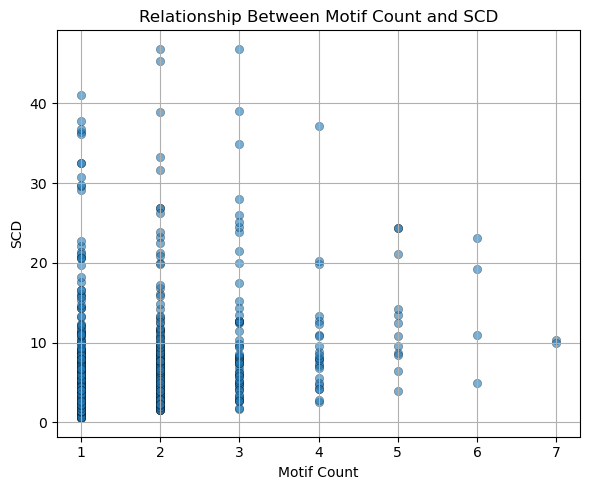

In [39]:
plt.figure(figsize=(6, 5))
plt.scatter(
    grouped_df["motif_count"],
    grouped_df["scd"],
    alpha=0.6,
    edgecolors="k",
    linewidths=0.3
)
plt.title("Relationship Between Motif Count and SCD")
plt.xlabel("Motif Count")
plt.ylabel("SCD")
plt.grid(True)
plt.tight_layout()
plt.show()

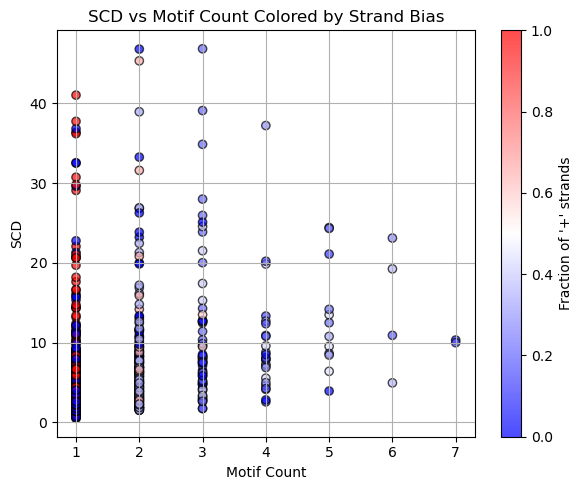

In [40]:
plt.figure(figsize=(6, 5))
plt.scatter(
    grouped_df["motif_count"],
    grouped_df["scd"],
    c=grouped_df["strand_bias"],
    cmap="bwr",  # blue (-) to red (+)
    alpha=0.7,
    edgecolors="k"
)
plt.colorbar(label="Fraction of '+' strands")
plt.title("SCD vs Motif Count Colored by Strand Bias")
plt.xlabel("Motif Count")
plt.ylabel("SCD")
plt.grid(True)
plt.tight_layout()
plt.show()

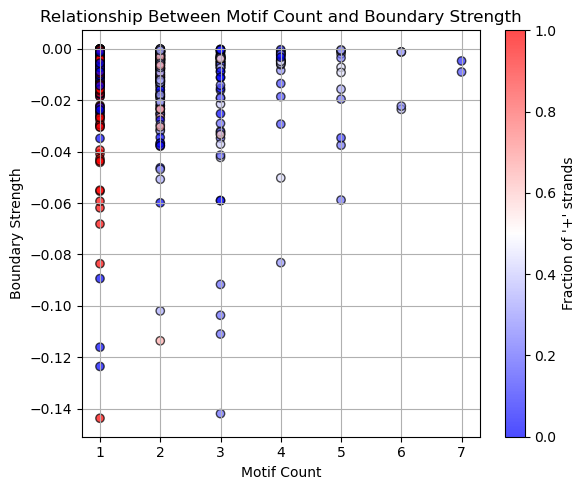

In [41]:

plt.figure(figsize=(6, 5))
plt.scatter(
    grouped_df["motif_count"],
    grouped_df["bound_strength"],
    c=grouped_df["strand_bias"],
    cmap="bwr",  # blue (-) to red (+)
    alpha=0.7,
    edgecolors="k"
)
plt.colorbar(label="Fraction of '+' strands")
plt.title("Relationship Between Motif Count and Boundary Strength")
plt.xlabel("Motif Count")
plt.ylabel("Boundary Strength")
plt.grid(True)
plt.tight_layout()
plt.show()

In [59]:
from scipy.stats import pearsonr

# Compute Pearson correlation
r, p = pearsonr(grouped_df["score_mean"], grouped_df["scd"])
corr_text = f"r = {r:.2f}, p = {p:.2e}"

In [60]:
corr_text

'r = 0.46, p = 4.09e-33'

In [61]:
x = grouped_df["score_mean"]
y = grouped_df["scd"]

# Fit line: y = m*x + b
m, b = np.polyfit(x, y, 1)

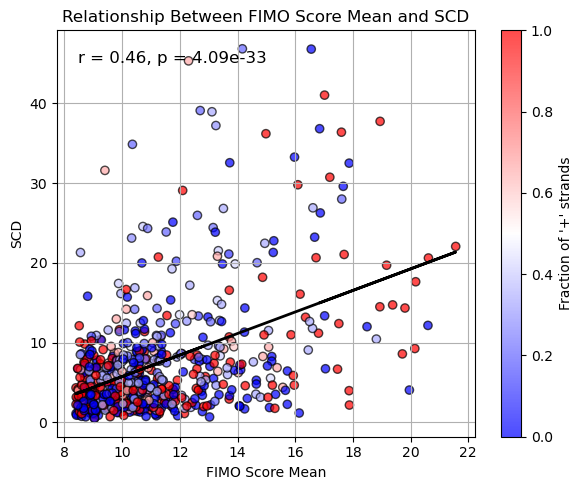

In [62]:
plt.figure(figsize=(6, 5))
plt.scatter(
    # grouped_df["score_sum"],
    grouped_df["score_mean"],
    grouped_df["scd"],
    c=grouped_df["strand_bias"],
    cmap="bwr",  # blue (-) to red (+)
    alpha=0.7,
    edgecolors="k"
)
plt.colorbar(label="Fraction of '+' strands")

plt.plot(x, m*x + b, color="black", linewidth=2, label=f"Fit: y = {m:.2f}x + {b:.2f}")

# Add correlation text in upper left
plt.text(0.05, 0.95, corr_text, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top')

plt.title("Relationship Between FIMO Score Mean and SCD")
plt.xlabel("FIMO Score Mean")
plt.ylabel("SCD")
plt.grid(True)
plt.tight_layout()
plt.show()

In [63]:
# Compute Pearson correlation
r, p = pearsonr(grouped_df["score_mean"], grouped_df["bound_strength"])
corr_text = f"r = {r:.2f}, p = {p:.2e}"

In [64]:
x = grouped_df["score_mean"]
y = grouped_df["bound_strength"]

# Fit line: y = m*x + b
m, b = np.polyfit(x, y, 1)

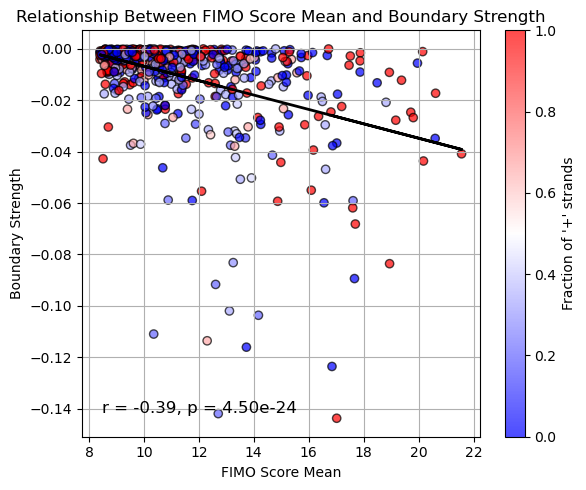

In [68]:
plt.figure(figsize=(6, 5))
plt.scatter(
    # grouped_df["score_sum"],
    grouped_df["score_mean"],
    grouped_df["bound_strength"],
    c=grouped_df["strand_bias"],
    cmap="bwr",  # blue (-) to red (+)
    alpha=0.7,
    edgecolors="k"
)
plt.colorbar(label="Fraction of '+' strands")

plt.plot(x, m*x + b, color="black", linewidth=2, label=f"Fit: y = {m:.2f}x + {b:.2f}")

# Add correlation text in upper left
plt.text(0.05, 0.05, corr_text, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='bottom')

plt.title("Relationship Between FIMO Score Mean and Boundary Strength")
plt.xlabel("FIMO Score Mean")
plt.ylabel("Boundary Strength")
plt.grid(True)
plt.tight_layout()
plt.show()

## Multiple CTCFs

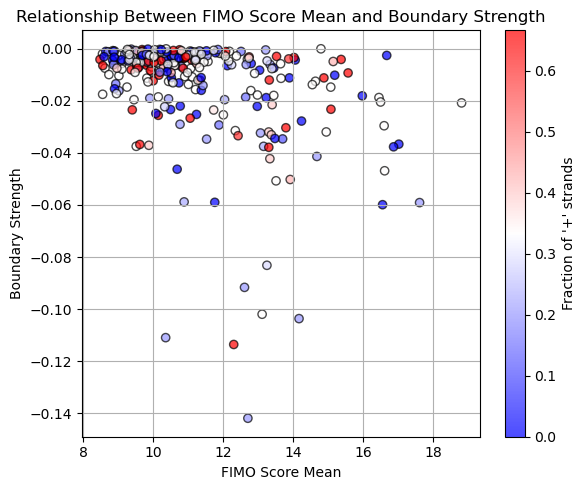

In [58]:
plt.figure(figsize=(6, 5))
plt.scatter(
    # grouped_df["score_sum"],
    multiple["score_mean"],
    multiple["bound_strength"],
    c=multiple["strand_bias"],
    cmap="bwr",  # blue (-) to red (+)
    alpha=0.7,
    edgecolors="k"
)
plt.colorbar(label="Fraction of '+' strands")
plt.title("Relationship Between FIMO Score Mean and Boundary Strength")
plt.xlabel("FIMO Score Mean")
plt.ylabel("Boundary Strength")
plt.grid(True)
plt.tight_layout()
plt.show()

In [52]:
multiple

,chrom,window_start,window_end,scd,bound_strength,score_mean,motif_count,strand_concat,strand_bias
0,chr1,5250784,6561504,7.888275,-0.016102,12.791343,2,"+,-",0.333333
1,chr1,6330784,7641504,5.610052,-0.001008,9.442425,2,"+,-",0.333333
2,chr1,6580784,7891504,34.867424,-0.110946,10.356293,3,"+,-,-",0.200000
3,chr1,8890784,10201504,7.899586,-0.001078,12.511220,4,"+,-,-,-",0.142857
5,chr1,16990784,18301504,2.081343,-0.004370,14.058471,2,"-,-",0.000000
...,...,...,...,...,...,...,...,...,...
608,chr9,64310784,65621504,8.529885,-0.011135,11.370834,3,"-,-,-",0.000000
609,chr9,66990784,68301504,31.598959,-0.023501,9.402447,2,"+,+",0.666667
610,chr9,70970784,72281504,2.302659,-0.000655,11.730926,2,"+,-",0.333333
612,chr9,82720784,84031504,9.490094,-0.003943,13.873070,3,"+,+,+",0.600000
